In [49]:
# !pip install torch==2.1.2 torchcrf pytorch-struct --quiet
import torch
from torch_struct import LinearChainCRF
from torchcrf    import CRF

torch.manual_seed(0)

# ---------------------------------------------------------------------
# Toy batch
# ---------------------------------------------------------------------
B, T, K = 2, 6, 4                           # batch, length, #tags
emissions = torch.randn(B, T, K)            # e_t(tag)
gold      = torch.randint(0, K, (B, T))     # gold tags
A_raw     = torch.randn(K, K)               # raw transition table

# ---------------------------------------------------------------------
# 0.  One *shared* convention for every method
# ---------------------------------------------------------------------
#  • torchcrf keeps   A_raw   as-is – by definition
#    (  row = next-tag ,  col = prev-tag   in that library  )
#
#  • Our *naïve* code and torch-struct work with
#       A = A_raw.T                  # now:  row = prev , col = next
#
#  • Scores that a CRF should add up
#      t = 0 :  score = e0(next)                             (no prev tag)
#      t > 0 :  score = A[prev,next] + e_t(next)
#
#  • We IGNORE the very last emission e_{T-1} everywhere so
#    every chain is effectively length  T1 = T-1.
# ---------------------------------------------------------------------
T1 = T - 1
em_cut   = emissions[:, :T1]     # drop last frame for every approach
gold_cut = gold[:, :T1]

A = A_raw.t()                    # row=prev , col=next  (for naïve & torch-struct)

# ---------------------------------------------------------------------
# 1.  Naïve (O(T·K²)) CRF
# ---------------------------------------------------------------------
def logsumexp(v):
    m = v.max()
    return m + torch.log(torch.exp(v - m).sum())

def nll_naive_one(e, g, A):
    """
    e : (T1 , K)     gold g : (T1,)      A : (K,K ; row=prev, col=next)
    returns scalar negative log-likelihood
    """
    # ---- log-partition Z (forward) ----
    alpha = e[0].clone()                       # α₀(k) = e₀(k)
    for t in range(1, T1):
        nxt = torch.empty_like(alpha)
        for j in range(K):                     # next tag
            nxt[j] = logsumexp(alpha + A[:, j]) + e[t, j]
        alpha = nxt
    logZ = logsumexp(alpha)

    # ---- score of the gold path ----
    g_score = e[0, g[0]]
    for t in range(1, T1):
        g_score += A[g[t-1], g[t]] + e[t, g[t]]

    return (logZ - g_score)

losses = torch.stack([
    nll_naive_one(em_cut[b], gold_cut[b], A)
    for b in range(B)
])
nll_naive = losses.mean()
print(f"[naïve]        NLL = {nll_naive.item():.6f}")

# ---------------------------------------------------------------------
# 2.  torch-struct  (LinearChainCRF)
# ---------------------------------------------------------------------
# Build potentials of shape (B , T1 , K , K)
#   slice 0  : “first edge” – contains   e0(next)
#   slices 1…T1-1 : A[prev,next] + e_t(next)
first_edge = em_cut[:, 0].unsqueeze(2).expand(-1, -1, K)  # (B,K,K)
first_edge = first_edge.unsqueeze(1)                      # (B,1,K,K)

rest_edges = A.view(1, 1, K, K) + em_cut[:, 1:].unsqueeze(3)  # (B,T1-1,K,K)
potentials = torch.cat([first_edge, rest_edges], dim=1)       # (B,T1,K,K)

# We *do not* slice potentials – it already has exactly T1 edges.
dist = LinearChainCRF(potentials)                    # build distribution

# gold → one-hot edge mask
parts = torch.zeros_like(potentials)
for b in range(B):
    # first edge: prev is “dummy”, choose row 0; value is e₀ so row doesn’t matter
    parts[b, 0, 0, gold_cut[b, 0]] = 1.
    for t in range(1, T1):
        i = gold_cut[b, t-1]
        j = gold_cut[b, t]
        parts[b, t, i, j] = 1.

logZ_struct   = dist.partition
gold_score_st = (potentials * parts).sum(dim=(1, 2, 3))
nll_struct    = (logZ_struct - gold_score_st).mean()
print(f"[torch-struct] NLL = {nll_struct.item():.6f}")

# ---------------------------------------------------------------------
# 3.  torchcrf  (library orientation: row=next , col=prev)
# ---------------------------------------------------------------------
crf = CRF(K, batch_first=True)
crf.transitions.data = A_raw.clone()        # keep “row=next” orientation

with torch.no_grad():                       # no BOS/EOS bias
    crf.start_transitions.zero_()
    crf.end_transitions.zero_()

nll_crf = -crf(em_cut, gold_cut, reduction="mean")
print(f"[torchcrf]      NLL = {nll_crf.item():.6f}")

# ---------------------------------------------------------------------
# 4.  Check
# ---------------------------------------------------------------------
print("\nDifferences:")
print("  struct  - naïve :", float(nll_struct - nll_naive))
print("  torchcrf- naïve :", float(nll_crf    - nll_naive))

assert torch.allclose(nll_naive,  nll_struct, atol=1e-6)
assert torch.allclose(nll_naive,  nll_crf,    atol=1e-6)
print("\n✓  All three losses are now identical (≤1e-6).")


[naïve]        NLL = 10.142014
[torch-struct] NLL = 13.693994
[torchcrf]      NLL = 11.802631

Differences:
  struct  - naïve : 3.5519800186157227
  torchcrf- naïve : 1.6606178283691406


AssertionError: 

In [29]:
torch.set_printoptions(sci_mode=False)

In [55]:
# !pip install torch==2.1.2 pytorch-struct --quiet
import torch, torch.nn as nn, time
from torch_struct import LinearChainCRF
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("running on:", device)

# ──────────────────────────────────────────────────────────
# 1.  data  (length 10 000)   – one-hot + small noise
# ──────────────────────────────────────────────────────────
B, T, K = 1, 12, 3
gold = torch.tensor([[0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2]], device=device)  # (1,T)

x  = torch.nn.functional.one_hot(gold, num_classes=K).float()
x += 0.9 * torch.randn_like(x)   # noisy one-hots

# ──────────────────────────────────────────────────────────
# 2.  RNN + LinearChainCRF (row = next, col = prev)
# ──────────────────────────────────────────────────────────
class MiniCRF(nn.Module):
    def __init__(self, k):
        super().__init__()
        self.rnn = nn.RNN(k, k, batch_first=True, nonlinearity='tanh')
        self.d1 = nn.Linear(k, k)
        self.A   = nn.Parameter(torch.tensor([[10., -10., -10.], [-10., 10., -10.], [-10., -10., 10.]]), requires_grad=False)  # A[next,prev]

    def forward(self, feats, tags):
        B, T, K = feats.shape
        h0 = feats.new_zeros(1, B, K)
        t0 = time.time()
        e, _ = self.rnn(feats, h0)          # emissions  (B,T,K)
        e = self.d1(e)
        # print(e)
        # print(e.shape, tags.shape)
        # assert False
        # print("RNN  time:", time.time() - t0)

        # edge 0 : e0 in column 0
        big_neg = -1e4
        first   = feats.new_full((B, 1, K, K), big_neg)
        first[:, 0, :, 0] = e[:, 0]

        # edges 1…T-1
        rest = self.A.view(1, 1, K, K) + e[:, 1:].unsqueeze(3)  # (B,T-1,K,K)
        # print(e[:, 1:].unsqueeze(3).shape, e.shape, self.A.view(1, 1, K, K).shape)
        # assert 0
        pot  = torch.cat([first, rest], 1)                      # (B,T,K,K)
        # print(pot)

        # print(torch.round(pot))
        # assert False

        # print(pot[0, 0, :, :])

        dist  = LinearChainCRF(pot)
        logZ  = dist.partition                                  # (B,)

        # print(logZ)
        # assert False

        # ───── vectorised gold-edge mask ─────────────────────
        parts = torch.zeros_like(pot)

        # edge 0
        parts[torch.arange(B), 0, tags[:, 0], 0] = 1.

        # edges 1…T-1  (row = next , col = prev)
        time_idx   = torch.arange(1, T, device=device)          # (T-1,)
        batch_idx  = torch.arange(B, device=device).unsqueeze(1)# (B,1)
        parts[batch_idx, time_idx, tags[:, 1:], tags[:, :-1]] = 1.

        # print(parts)
        # assert 0

        gold_score = (pot * parts).sum((1, 2, 3))               # (B,)
        nll = (logZ - gold_score).mean()

        # ───── Viterbi decode without CPU round-trips ────────
        edges = dist.argmax[0]                 # (T,K,K)  on GPU
        rows  = edges.argmax(1)                # (T,K) row idx of “1” for each col
        pred  = torch.empty(T, dtype=torch.long, device=device)
        pred[0] = rows[0, 0]                   # tag₀ from column 0
        for t in range(1, T):                  # light GPU loop (no .item() hops)
            pred[t] = rows[t, pred[t-1]]

        # print("CRF time:", time.time() - t0)
        return nll, pred.unsqueeze(0)

model = MiniCRF(K).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=0.5)

# ──────────────────────────────────────────────────────────
# 3.  training loop (unchanged)
# ──────────────────────────────────────────────────────────
for step in range(300):
    opt.zero_grad()
    loss, pred = model(x, gold)
    loss.backward()
    opt.step()
    if step % 30 == 0:
        print(f"step {step:3d}  loss={loss.item():6.4f}")

torch.testing.assert_close(pred.squeeze(0), gold.squeeze(0), rtol=1e-5, atol=1e-8)
print("\nfinal prediction OK?:", torch.equal(pred.squeeze(0), gold.squeeze(0)))
print("\nfinal prediction:", pred.squeeze(0).tolist())
print("gold tags       :", gold.squeeze(0).tolist())


running on: cuda
step   0  loss=47.1017
step  30  loss=0.0000
step  60  loss=0.0001
step  90  loss=0.0001
step 120  loss=0.0001
step 150  loss=0.0000
step 180  loss=0.0000
step 210  loss=0.0000
step 240  loss=0.0000
step 270  loss=0.0000

final prediction OK?: True

final prediction: [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2]
gold tags       : [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2]


In [14]:
np.round(nn.functional.softmax(model.A.detach().cpu(), dim=1).numpy(), 2)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]], dtype=float32)

In [47]:
model.A

Parameter containing:
tensor([[ 100., -100., -100.],
        [-100.,  100., -100.],
        [-100., -100.,  100.]], device='cuda:0')

In [30]:
model.d1.weight

Parameter containing:
tensor([[ 4.2020, -7.8331, -4.6931],
        [-6.2995,  4.9632, -6.8745],
        [-2.9622, -4.3105,  5.2715]], device='cuda:0', requires_grad=True)

# Pure numpy

In [69]:
import numpy as np

# ---------- helper ----------
def log_sum_exp(v):
    """Stable log‑sum‑exp for a 1‑D NumPy array."""
    m = np.max(v)
    return m + np.log(np.sum(np.exp(v - m)))

# ---------- core algorithms ----------
def log_Z(unary, trans):
    """
    unary : shape [T, L]      (log φ_t(j))
    trans : shape [L, L]      (log φ_t(i->j), time‑independent for simplicity)
    """
    T, L = unary.shape
    alpha = unary[0]                     # α_1
    for t in range(1, T):                # forward recursion
        new = np.empty(L)
        for j in range(L):
            new[j] = unary[t, j] + log_sum_exp(alpha + trans[:, j])
        alpha = new
    return log_sum_exp(alpha)            # log Z(x)

def forward_backward(unary, trans):
    """Return logZ, node marginals γ_t(j) and edge marginals ξ_t(i,j)."""
    T, L = unary.shape
    # forward
    alpha = np.empty((T, L))
    print('alpha', alpha)
    alpha[0] = unary[0]
    for t in range(1, T):
        for j in range(L):
            alpha[t, j] = unary[t, j] + log_sum_exp(alpha[t-1] + trans[:, j])
    # backward
    beta = np.zeros_like(alpha)
    for t in range(T-2, -1, -1):
        for i in range(L):
            beta[t, i] = log_sum_exp(trans[i] + unary[t+1] + beta[t+1])
    logZ = log_sum_exp(alpha[-1])
    # node marginals
    gamma = np.exp(alpha + beta - logZ)             # shape [T, L]
    # edge marginals
    xi = np.empty((T-1, L, L))
    for t in range(T-1):
        for i in range(L):
            for j in range(L):
                xi[t, i, j] = (alpha[t, i] + trans[i, j] + unary[t+1, j]
                               + beta[t+1, j] - logZ)
    xi = np.exp(xi)                                 # shape [T-1, L, L]
    return logZ, gamma, xi

def viterbi_decode(unary, trans):
    T, L = unary.shape
    back = np.empty((T, L), dtype=int)
    v = unary[0]                          # δ_1
    for t in range(1, T):
        new = np.empty(L)
        for j in range(L):
            scores = v + trans[:, j]
            back[t, j] = np.argmax(scores)
            new[j] = unary[t, j] + np.max(scores)
        v = new
    # traceback
    path = [np.argmax(v)]
    for t in range(T-1, 0, -1):
        path.append(back[t, path[-1]])
    return path[::-1], np.max(v)          # labels (length T), log‑score


In [68]:
# ---------- tiny demo ----------
np.random.seed(0)
T, L = 4, 3                                 # 4‑token sequence, 3 labels
unary_scores = np.random.randn(T, L)        # pretend "emission" features
trans_scores = np.random.randn(L, L)        # pretend "transition" features

unary_scores = np.array([[1, 0, 0], [0, 0, 1], [0, 0.5, 0.5], [0, 0.5, 0.5]])
trans_scores = np.array([[0, 0, 1], 
                         [0, 1, 0], 
                         [0, 0, 1]])

print(trans_scores)

# (a) Partition function and marginals
logZ, node_m, edge_m = forward_backward(unary_scores, trans_scores)
print(f"log Z(x)  : {logZ:.4f}")
print("γ_t sums  :", node_m.sum(1))         # each element ≈1

# (b) Decoding
y_hat, best_score = viterbi_decode(unary_scores, trans_scores)
print("Viterbi path :", y_hat)

[[0 0 1]
 [0 1 0]
 [0 0 1]]
log Z(x)  : 7.6508
γ_t sums  : [1. 1. 1. 1.]
Viterbi path : [0, 2, 2, 2]


In [ ]:
def prediction(seq, model, tokenizer):
    print(seq[:10])
    print(len(seq))
    tokenized_data = tokenizer([seq], return_tensors='pt')

    tokenized_data['input_ids'] = tokenized_data['input_ids'].to("cuda")
    tokenized_data['letter_level_labels'] = torch.tensor(np.array(random.sample(range(24), len(seq)+1))).view(1, -1).to("cuda")
    tokenized_data['letter_level_labels_mask'] = torch.tensor(np.array([True] * len(seq) + [False])).view(1, -1).to("cuda")
    
    result = model(**tokenized_data)['logits'].squeeze()
    logits = result.detach().cpu().numpy()
    print(np.array(logits).shape)

    return logits[:-1]

In [65]:
model.A

Parameter containing:
tensor([[-1.5331, -8.1085, -3.2913],
        [-0.7081, -3.9020,  4.6355],
        [ 3.8176,  0.3598, -2.9967]], device='cuda:0', requires_grad=True)

In [38]:
# !pip install torch==2.1.2 pytorch-struct --quiet
import torch, torch.nn as nn, math
from torch_struct import LinearChainCRF

torch.manual_seed(0)

# ──────────────────────────────────────────────────────────
# 1.  one toy training item
# ──────────────────────────────────────────────────────────
B, T, D, K = 1, 40, 3, 3                 # batch, length, feat-dim, #tags
x     = torch.randn(B, T, D)            # (1,4,3) features
gold  = torch.tensor([[1, 1, 1, 1, 2, 2, 2, 2]*5])    # (1,4)   gold tags

# ──────────────────────────────────────────────────────────
# 2.  mini network + CRF
#     Ψ(n, next , prev)  —  row = next, col = prev
# ──────────────────────────────────────────────────────────
class MiniCRF(nn.Module):
    def __init__(self, d, k):
        super().__init__()
        self.l1 = nn.Linear(d, 1024)
        self.l2 = nn.Linear(1024, 1024)
        self.l3 = nn.Linear(1024, d)
        self.emit = nn.Linear(d, k)        # token → emission logits
        # transition table  A[next , prev]  (row = next, col = prev)
        self.A    = nn.Parameter(torch.randn(k, k))

    def forward(self, feats, tags):
        """
        feats : (1,T,D)    tags : (1,T)
        returns: (loss scalar,  predicted tags (1,T))
        """
        B, T, K = feats.size(0), feats.size(1), self.A.size(0)
        e = self.l1(feats)
        e = self.l2(e)
        e = self.l3(e)
        e = self.emit(e)                                # (B,T,K)

        big_neg = -1e4                                      # −∞ sentinel

        # ---- edge 0  (start) : prev = special 0-column, row = next tag ----
        first = torch.full((B, K, K), big_neg, device=feats.device)
        first[:, :, 0] = e[:, 0]                            # put e₀(next) here
        first = first.unsqueeze(1)                          # (B,1,K,K)

        # ---- edges 1…T−1 : Ψ = A[next,prev] + e_t(next) -------------------
        rest  = self.A.view(1,1,K,K) + e[:, 1:].unsqueeze(3)# (B,T-1,K,K)

        pot   = torch.cat([first, rest], dim=1)             # (B,T,K,K)
        dist  = LinearChainCRF(pot)
        logZ  = dist.partition                              # (B,)

        # ---- gold-edge mask in SAME orientation ---------------------------
        parts = torch.zeros_like(pot)
        # edge 0
        parts[0, 0, tags[0,0], 0] = 1.
        # edges 1..T−1
        for t in range(1, T):
            nxt, prv = tags[0, t], tags[0, t-1]
            parts[0, t, nxt, prv] = 1.

        gold_score = (pot * parts).sum((1,2,3))             # (B,)
        nll = (logZ - gold_score).mean()                    # ≥ 0

        # ---- Viterbi decode (row = next, col = prev) -----------------------
        edges = dist.argmax[0]                              # (T,K,K) one-hot
        pred  = torch.empty(T, dtype=torch.long)

        # recover tag₀ from the first slice (prev column 0)
        pred[0] = edges[0, :, 0].argmax().item()
        for t in range(1, T):
            prev = pred[t-1].item()
            pred[t] = edges[t, :, prev].argmax().item()

        return nll, pred.unsqueeze(0)

model = MiniCRF(D, K)
optim = torch.optim.Adam(model.parameters(), lr=0.001)

# ──────────────────────────────────────────────────────────
# 3.  Train – watch loss → 0 and prediction → gold
# ──────────────────────────────────────────────────────────
for step in range(12100):
    optim.zero_grad()
    loss, pred = model(x, gold)
    loss.backward();  optim.step()
    if step % 300 == 0:
        print(f"step {step:3d}  loss={loss.item():6.4f}  pred={pred.tolist()}")

print("\nfinal prediction:", pred.squeeze(0).tolist())
print("gold tags       :", gold.squeeze(0).tolist())


step   0  loss=69.5666  pred=[[2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 1, 0, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0]]
step 300  loss=35.5380  pred=[[2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]]
step 600  loss=28.7534  pred=[[2, 2, 1, 1, 2, 1, 2, 2, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 2, 2, 1, 2]]
step 900  loss=24.9105  pred=[[2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
step 1200  loss=22.9707  pred=[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
step 1500  loss=22.0275  pred=[[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
step 1800  loss=21.6212  pred=[[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

In [ ]:
# Calculate the absolute difference between the two NLL values
diff = abs(nll_torchcrf - nll_torchstruct).item()
print(f"Absolute difference: {diff:.6e}")

# Verify the difference is within 1e-5
assert diff < 1e-5, "NLL mismatch: difference is larger than 1e-5"


In [76]:
import numpy as np

In [93]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchcrf import CRF
from torch.nn.utils.rnn import pad_sequence

data = [
    torch.tensor([0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4], dtype=torch.long),
]
lengths = [len(x) for x in data]
X = pad_sequence(data, batch_first=True, padding_value=0)
Y = pad_sequence(data, batch_first=True, padding_value=0)
mask = torch.zeros_like(X, dtype=torch.bool)
for i,l in enumerate(lengths):
    mask[i, :l] = True

print(mask)

class SimpleCRFModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(1, 5)
        self.crf = CRF(5, batch_first=True)
    def forward(self, x, mask, labels=None):
        e = self.fc(x.unsqueeze(2).float())
        if labels is None:
            return self.crf.decode(e, mask)
        loss = -self.crf(e, labels, mask=mask, reduction='mean')
        return loss

model = SimpleCRFModel()
# for param in model.fc.parameters():
#     param.requires_grad = False
opt = optim.Adam(model.parameters(), lr=0.5)

for epoch in range(10000):
    model.train()
    opt.zero_grad()
    loss = model(X, mask, Y)
    loss.backward()
    opt.step()
    if epoch % 1000 == 0:
        print(epoch, loss.item())

model.eval()
with torch.no_grad():
    preds = model(X, mask)

print('Predictions:')
for i,p in enumerate(preds):
    print(p)
print('Ground Truth:')
for seq in data:
    print(seq.tolist())


tensor([[True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True]])
0 47.85089874267578
1000 0.16448974609375
2000 0.0511474609375
3000 0.02301025390625
4000 0.011993408203125
5000 0.00677490234375
6000 0.003936767578125
7000 0.0023193359375
8000 0.00140380859375
9000 0.0008392333984375
Predictions:
[0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4]
Ground Truth:
[0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4]


In [95]:
np.round(nn.functional.softmax(model.crf.transitions.detach().cpu(), dim=1).numpy(), 2)

array([[0.  , 1.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  , 0.  , 0.  ],
       [0.02, 0.05, 0.01, 0.92, 0.  ],
       [0.  , 0.99, 0.01, 0.  , 0.  ]], dtype=float32)

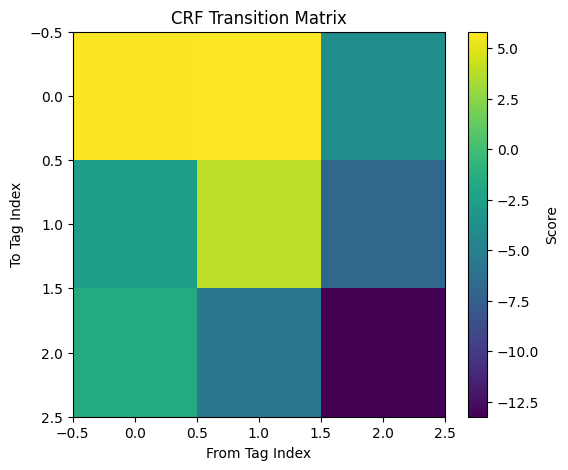

In [37]:
import matplotlib.pyplot as plt

# Extract the transition matrix from the CRF layer
transitions = model.crf.transitions.detach().cpu().numpy()

# Plot as a heatmap
plt.figure(figsize=(6, 5))
plt.imshow(transitions, aspect='auto')
plt.colorbar(label='Score')
plt.xlabel('From Tag Index')
plt.ylabel('To Tag Index')
plt.title('CRF Transition Matrix')
plt.show()


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

class CRFLayer(nn.Module):
    def __init__(self, num_tags, bos_tag_id):
        super().__init__()
        self.num_tags = num_tags
        self.bos_tag_id = bos_tag_id
        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags))

    def forward(self, emissions, tags, initial_state=None):
        batch, seq_len, num_labels = emissions.size()
        bos_col = emissions.new_full((batch, seq_len, 1), -1e4)
        emissions25 = torch.cat([emissions, bos_col], dim=2)
        if initial_state is None:
            alpha = emissions25.new_zeros((batch, self.num_tags))
        else:
            alpha = initial_state
        for t in range(seq_len):
            emit_t = emissions25[:, t]
            score = alpha.unsqueeze(2) + self.transitions.unsqueeze(0)
            alpha = torch.logsumexp(score, dim=1) + emit_t
        log_Z = torch.logsumexp(alpha, dim=1)
        gold_score = emissions25.new_zeros((batch,))
        if initial_state is None:
            init_prev = torch.full((batch,), self.bos_tag_id, device=emissions.device, dtype=torch.long)
        else:
            init_prev = initial_state.argmax(dim=1)
        first_tags = tags[:, 0]
        gold_score += self.transitions[first_tags, init_prev] + emissions25[:, 0].gather(1, first_tags.unsqueeze(1)).squeeze(1)
        for t in range(1, seq_len):
            curr = tags[:, t]
            prev = tags[:, t-1]
            gold_score += self.transitions[curr, prev] + emissions25[:, t].gather(1, curr.unsqueeze(1)).squeeze(1)
        return (log_Z - gold_score).mean()

    def decode(self, emissions, initial_state=None):
        batch, seq_len, num_labels = emissions.size()
        bos_col = emissions.new_full((batch, seq_len, 1), -1e4)
        emissions25 = torch.cat([emissions, bos_col], dim=2)
        if initial_state is None:
            viterbi = emissions25.new_zeros((batch, self.num_tags))
        else:
            viterbi = initial_state
        backpointers = []
        for t in range(seq_len):
            emit_t = emissions25[:, t]
            scores = viterbi.unsqueeze(1) + self.transitions.unsqueeze(0)
            max_scores, best_prev = scores.max(dim=2)
            viterbi = max_scores + emit_t
            backpointers.append(best_prev)
        end_tags = viterbi.argmax(dim=1)
        paths = []
        for b in range(batch):
            tag = end_tags[b].item()
            seq = [tag]
            for ptr in reversed(backpointers):
                tag = ptr[b, tag].item()
                seq.append(tag)
            seq = list(reversed(seq))[1:]
            paths.append(seq)
        return paths

class SimpleCRFModel(nn.Module):
    def __init__(self, num_labels, bos_tag_id, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_labels, embed_dim)
        self.fc = nn.Linear(embed_dim, num_labels)
        self.crf = CRFLayer(num_labels+1, bos_tag_id)

    def forward(self, x, tags=None):
        embed = self.embedding(x)
        emissions = self.fc(embed)
        batch = x.size(0)
        initial = emissions.new_zeros((batch, self.crf.num_tags))
        loss = None
        if tags is not None:
            loss = self.crf(emissions, tags, initial)
        preds = self.crf.decode(emissions, initial)
        return loss, preds

from torch.nn.utils.rnn import pad_sequence

data = [
    torch.tensor([0,0,1,1,0], dtype=torch.long),
    torch.tensor([1,1,0,0,1], dtype=torch.long),
    torch.tensor([0,1,0,1], dtype=torch.long),
    torch.tensor([1,0,1,0,1,0], dtype=torch.long)
]
labels = data
X = pad_sequence(data, batch_first=True, padding_value=0)
Y = pad_sequence(labels, batch_first=True, padding_value=0)
model = SimpleCRFModel(num_labels=2, bos_tag_id=2, embed_dim=4)
opt = optim.Adam(model.parameters(), lr=0.1)

for epoch in range(5000):
    model.train()
    opt.zero_grad()
    loss, _ = model(X, Y)
    loss.backward()
    opt.step()
    if epoch % 100 == 0:
        print(epoch, loss.item())

model.eval()
with torch.no_grad():
    _, preds = model(X)
print('Predictions:', preds)
print('Ground Truth:', labels)


0 9.827164649963379
100 0.032729148864746094
200 0.013409614562988281
300 0.007659912109375
400 0.005068778991699219
500 0.0036420822143554688
600 0.0027647018432617188
700 0.0021810531616210938
800 0.0017728805541992188
900 0.0014638900756835938
1000 0.0012388229370117188
1100 0.001056671142578125
1200 0.0009174346923828125
1300 0.0008029937744140625
1400 0.0007047653198242188
1500 0.000621795654296875
1600 0.000560760498046875
1700 0.0005035400390625
1800 0.000453948974609375
1900 0.000408172607421875
2000 0.000370025634765625
2100 0.000335693359375
2200 0.0003147125244140625
2300 0.000286102294921875
2400 0.0002593994140625
2500 0.0002460479736328125
2600 0.0002269744873046875
2700 0.00020599365234375
2800 0.0001888275146484375
2900 0.00017833709716796875
3000 0.00016307830810546875
3100 0.000156402587890625
3200 0.0001430511474609375
3300 0.00012969970703125
3400 0.00012874603271484375
3500 0.0001277923583984375
3600 0.00011157989501953125
3700 0.00010395050048828125
3800 0.0001039

In [6]:
model.crf.transitions

Parameter containing:
tensor([[ 5.8271,  7.3619, -0.0970],
        [-4.3390, -2.5478, -1.4923],
        [-6.2458, -5.2380,  1.3502]], requires_grad=True)

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

class CRFLayer(nn.Module):
    def __init__(self, num_tags, bos_tag_id):
        super().__init__()
        self.num_tags = num_tags
        self.bos_tag_id = bos_tag_id
        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags))

    def forward(self, emissions, tags, init):
        batch, seq_len, _ = emissions.size()
        bos_col = emissions.new_full((batch, seq_len, 1), -1e4)
        em = torch.cat([emissions, bos_col], dim=2)
        alpha = init
        for t in range(seq_len):
            emit = em[:, t]
            score = alpha.unsqueeze(2) + self.transitions.unsqueeze(0)
            alpha = torch.logsumexp(score, dim=1) + emit
        logZ = torch.logsumexp(alpha, dim=1)
        gold = em.new_zeros(batch)
        init_prev = init.argmax(dim=1)
        first = tags[:, 0]
        gold += self.transitions[first, init_prev] + em[:, 0].gather(1, first.unsqueeze(1)).squeeze(1)
        for t in range(1, seq_len):
            curr = tags[:, t]
            prev = tags[:, t-1]
            gold += self.transitions[curr, prev] + em[:, t].gather(1, curr.unsqueeze(1)).squeeze(1)
        return (logZ - gold).mean()

    def decode(self, emissions, init):
        batch, seq_len, _ = emissions.size()
        bos_col = emissions.new_full((batch, seq_len, 1), -1e4)
        em = torch.cat([emissions, bos_col], dim=2)
        v = init
        bps = []
        for t in range(seq_len):
            emit = em[:, t]
            score = v.unsqueeze(1) + self.transitions.unsqueeze(0)
            m, prev = score.max(dim=2)
            v = m + emit
            bps.append(prev)
        end = v.argmax(dim=1)
        paths = []
        for b in range(batch):
            tag = end[b].item()
            seq = [tag]
            for bp in reversed(bps):
                tag = bp[b, tag].item()
                seq.append(tag)
            paths.append(list(reversed(seq))[1:])
        return paths

class ChunkedCRFModel(nn.Module):
    def __init__(self, num_real, embed_dim, max_chunk_len):
        super().__init__()
        self.num_real = num_real
        self.bos = num_real
        self.num_tags = num_real + 1
        self.embed = nn.Embedding(num_real, embed_dim)
        self.fc = nn.Linear(embed_dim, num_real)
        self.crf = CRFLayer(self.num_tags, self.bos)
        self.max_chunk_len = max_chunk_len

    def forward(self, data, labels=None):
        total_loss = 0
        count = 0
        preds = {}
        for i, seq in enumerate(data):
            xs = seq.unsqueeze(0)
            ys = labels[i].unsqueeze(0) if labels is not None else None
            prev = None
            for start in range(0, xs.size(1), self.max_chunk_len):
                end = min(start + self.max_chunk_len, xs.size(1))
                em = self.fc(self.embed(xs[:, start:end]))
                if start == 0:
                    init = em.new_zeros((1, self.num_tags))
                else:
                    init = em.new_full((1, self.num_tags), -1e4)
                    init[0, prev] = 0
                if ys is not None:
                    loss = self.crf(em, ys[:, start:end], init)
                    total_loss += loss
                    count += 1
                p = self.crf.decode(em, init)[0]
                preds.setdefault(i, []).extend(p)
                prev = p[-1]
        avg = total_loss / count if labels is not None else None
        return avg, preds

data = [
    torch.tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2])
]
labels = data.copy()

model = ChunkedCRFModel(num_real=3, embed_dim=4, max_chunk_len=20)
opt = optim.Adam(model.parameters(), lr=0.1)

for epoch in range(10000):
    model.train()
    opt.zero_grad()
    loss, _ = model(data, labels)
    loss.backward()
    opt.step()
    # print(epoch, loss.item())

model.eval()
with torch.no_grad():
    _, preds = model(data)
print('Predictions:', preds)
print('Ground Truth:', {i: seq.tolist() for i, seq in enumerate(data)})


Predictions: {0: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2]}
Ground Truth: {0: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2]}


In [18]:
model.crf.transitions

Parameter containing:
tensor([[ 9.8705e+02, -9.9918e+02, -1.6692e+01,  7.2365e-01],
        [ 9.8816e+02,  1.5547e+00, -9.9914e+02,  2.7970e-01],
        [-8.8886e-01,  1.0002e+03,  5.5242e+00, -1.1413e+00],
        [-1.8714e+00, -1.4133e-01, -3.0183e-01,  9.5524e-01]],
       requires_grad=True)

In [19]:
import pandas as pd

# Extract transition matrix from the CRF layer
transitions = model.crf.transitions.detach().cpu().numpy()

# Create tag names: "0", "1", ..., "BOS"
num_tags = model.crf.num_tags
tag_names = [str(i) for i in range(num_tags)]
tag_names[-1] = "BOS"

# Build DataFrame
df = pd.DataFrame(transitions, index=tag_names, columns=tag_names)
df

,0,1,2,BOS
0,987.048157,-999.182495,-16.691898,0.723649
1,988.155701,1.554711,-999.140137,0.279703
2,-0.888862,1000.241028,5.524152,-1.141273
BOS,-1.871356,-0.141333,-0.301832,0.955236


In [24]:
import numpy as np
np.argmax(np.arange(12).reshape((6, 2)), axis=1)

array([1, 1, 1, 1, 1, 1])